In [1]:
import pandas as pd
from protocols import functions, utils

from catomatic.BinaryCatalogue import BinaryBuilder

%load_ext autoreload
%autoreload 2

In [2]:
# the path to the CRyPTIC v3.1.0 data tables (including the DST_MEASUREMENTS_+.pkl which has DST for the validation samples appended)
cryptic_tables_path = '/Users/fowler/Dropbox/files/cryptic/cryptic-release-three/cryptic-tables-v3.1.0/'


In [3]:
phenotypes = functions.prep_phenotypes('RIF', 
                             cryptic_tables_path+'DST_MEASUREMENTS_+.pkl', 
                             cryptic_tables_path+'GENOMES.parquet',  
                             cryptic_tables_path+'WGS_SAMPLES.parquet', 
                             version='v1.0')
phenotypes[:5]

,UNIQUEID,DRUG,PHENOTYPE,METHOD_MIC,METHOD_3
0,site.00.subj.1000347.lab.H111540004.iso.1,RIF,R,NaN,resistance ratio
1,site.00.subj.1000595.lab.H123460044.iso.1,RIF,R,NaN,resistance ratio
2,site.00.subj.1004213.lab.H111060034.iso.1,RIF,R,NaN,resistance ratio
3,site.00.subj.1004213.lab.H112000008.iso.1,RIF,R,NaN,resistance ratio
4,site.00.subj.1004213.lab.H113100007.iso.1,RIF,R,NaN,resistance ratio


In [4]:
mutations = functions.prep_mutations('data/mutations-v3.1.0/', 
                           ['rpoB'], 
                           version='v3.1.0', 
                           mut_path=cryptic_tables_path+'MUTATIONS.parquet', 
                           var_path=cryptic_tables_path+'VARIANTS.parquet')
mutations[:5]

,UNIQUEID,MUTATION,FRS
0,site.02.subj.0069.lab.22A019.iso.1,rpoB@S450L,1.0
4,site.03.subj.6236-05_LIB12062.lab.6236-05_LIB1...,rpoB@S450L,1.0
5,site.04.subj.00255.lab.709124.iso.1,rpoB@S450L,1.0
8,site.06.subj.RLH_0305-14.lab.06MIL0297.iso.1,rpoB@c-61t,1.0
9,site.06.subj.RLH_0305-14.lab.06MIL0297.iso.1,rpoB@S450L,1.0


In [5]:
catalogue = BinaryBuilder(
                samples=phenotypes, 
                mutations=mutations, 
                FRS=0.1
            )

catalogue.build(test='Binomial', background=0.2, strict_unlock=True, p=0.95)

catalogue_df = catalogue.build_piezo(
                    genbank_ref='NC00962.3',
                    catalogue_name='rif_demo', 
                    version='0.0', 
                    drug='RIF', 
                    wildcards="./data/wildcards/rif_wildcards.json", 
                    json_dumps=True
                )

catalogue_df.to_csv('./catalogues/temp/demo_rif_catalogue.csv')

catalogue_df

,GENBANK_REFERENCE,CATALOGUE_NAME,CATALOGUE_VERSION,CATALOGUE_GRAMMAR,PREDICTION_VALUES,DRUG,MUTATION,PREDICTION,SOURCE,EVIDENCE,OTHER
0,NC00962.3,rif_demo,0.0,GARC1,RUS,RIF,rpoB@c-61t,S,{},"{""proportion"": 0.007196162046908316, ""confiden...",{}
1,NC00962.3,rif_demo,0.0,GARC1,RUS,RIF,rpoB@2546_ins_cgagga,S,{},"{""proportion"": 0.0, ""confidence"": [0.0, 0.0687...",{}
2,NC00962.3,rif_demo,0.0,GARC1,RUS,RIF,rpoB@E250G,S,{},"{""proportion"": 0.043010752688172046, ""confiden...",{}
3,NC00962.3,rif_demo,0.0,GARC1,RUS,RIF,rpoB@L449Q,S,{},"{""proportion"": 0.0, ""confidence"": [0.0, 0.0770...",{}
4,NC00962.3,rif_demo,0.0,GARC1,RUS,RIF,rpoB@V695L,S,{},"{""proportion"": 0.056338028169014086, ""confiden...",{}
...,...,...,...,...,...,...,...,...,...,...,...
408,NC00962.3,rif_demo,0.0,GARC1,RUS,RIF,rpoB@-*_indel,U,{},"{""default_rule"": ""True""}",{}
409,NC00962.3,rif_demo,0.0,GARC1,RUS,RIF,rpoB@*_indel,U,{},"{""default_rule"": ""True""}",{}
410,NC00962.3,rif_demo,0.0,GARC1,RUS,RIF,rpoB@-*?,U,{},"{""default_rule"": ""True""}",{}
411,NC00962.3,rif_demo,0.0,GARC1,RUS,RIF,rpoB@*?,U,{},"{""default_rule"": ""True""}",{}


In [6]:
#test performance on training set

#note, this merge assumes the phenotypes df only contains samples that have been genotyped
all = pd.merge(phenotypes, mutations[mutations.FRS>=0.1], on=['UNIQUEID'], how='left')

cmatrix = utils.piezo_predict(iso_df=all, drug='RIF', catalogue_file='./catalogues/temp/demo_rif_catalogue.csv', Print=True)[0]

cmatrix= pd.DataFrame(cmatrix, index=["R", "S"], columns=["R", "S", 'U'])

cmatrix

[[ 9997   380   252]
 [  380 23767   936]]
Catalogue coverage of isolates: 0.9667338709677419
Sensitivity: 0.9633805531463814
Specificity: 0.984263055452023


,R,S,U
R,9997,380,252
S,380,23767,936


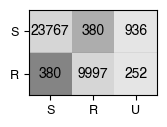

In [7]:
utils.plot_truthtables(cmatrix, U_to_S=False, save='figs/truthtable-RIF-exemplar.pdf', colors=["#666666", "#cccccc", "#999999", "#cccccc","#cccccc","#cccccc" ])